In [2]:
import pandas as pd
import numpy as np

# Importar librerias de visualización
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df_1= pd.read_csv("../data/bank-estandarizado.csv")
df_2= pd.read_csv("../data/output/customer-details-unido.csv")

pd.set_option('display.max_columns', None)

In [4]:
df_1.sample(5)

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,ID,duration_reduce,campaign_reduce,previous_reduce
2345,55.0,retired,married,basic.6y,no registrado,0,0,telephone,129,1,no contacted,0,nonexistent,1.1,93.994,-36.4,4.856,5191.0,no,2018-09-22,4d2ade8a-78d4-4e76-8f62-d672de6815de,129.0,1,0
3299,26.0,entrepreneur,married,university.degree,No,0,0,telephone,73,2,no contacted,0,nonexistent,1.1,93.994,-36.4,4.860,5191.0,no,2018-12-24,3b966515-5b2c-43f0-b042-df19bdbfc697,73.0,2,0
39598,26.0,unemployed,married,basic.4y,No,0,0,telephone,29,1,no contacted,0,nonexistent,-1.8,93.876,-40.0,0.699,5008.7,no,2017-12-14,5ff0a24d-153d-4c87-99fb-f930af004776,29.0,1,0
21984,38.0,self-employed,married,professional.course,No,1,0,cellular,181,3,no contacted,0,nonexistent,1.4,93.444,-36.1,4.964,5228.1,no,2015-05-15,4941e960-7a03-4894-b436-762a08bf1bdb,181.0,3,0
25489,49.0,blue-collar,married,basic.9y,no registrado,0,0,cellular,227,4,no contacted,0,nonexistent,-0.1,93.200,-42.0,4.857,5195.8,no,2019-03-08,021667fe-4cf7-44a3-b9de-6d1d8cd26333,227.0,4,0


In [5]:
df_2.sample(3)

,income,kidhome,teenhome,dt_customer,numwebvisitsmonth,ID,año
37795,31653,2,2,2014-08-24,23,bab93c3d-841d-4882-8bdb-ba118d80952c,2014
459,154609,2,0,2012-11-08,22,c6fb1d47-2107-481c-9982-a7d3d72e846f,2012
18833,167801,1,0,2012-08-15,31,f19baf7e-aa7b-4073-add5-233868b0f81a,2012


usamos merge left, ya que queremos que del primer DF nos aparezcan todos los datos relacionados con la estadistica realizada sobre las campañas y queremos que estas filas se nos completen con los datos que tenemos sobre otros detalles adicionales, si en este otro archivo hay otros clientes sobre los que no se ha realizado la campaña no nos interesa tenerlos en nuestro DF. Tambien podríamos utilizar "inner", pero si en algun caso faltara algun dato en el segundo DF, se nos perdería dicho dato de nuestro DF principal.

In [ ]:
df =pd.merge(df_1, df_2, on="ID", how="left")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                43000 non-null  float64
 1   job                43000 non-null  object 
 2   marital            43000 non-null  object 
 3   education          43000 non-null  object 
 4   default            43000 non-null  object 
 5   housing            43000 non-null  int64  
 6   loan               43000 non-null  int64  
 7   contact            43000 non-null  object 
 8   duration           43000 non-null  int64  
 9   campaign           43000 non-null  int64  
 10  pdays              43000 non-null  object 
 11  previous           43000 non-null  int64  
 12  poutcome           43000 non-null  object 
 13  emp.var.rate       43000 non-null  float64
 14  cons.price.idx     43000 non-null  float64
 15  cons.conf.idx      43000 non-null  float64
 16  euribor3m          430

In [31]:
df.sample(3)

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,ID,duration_reduce,campaign_reduce,previous_reduce,income,kidhome,teenhome,dt_customer,numwebvisitsmonth,año,y_boo,income_group,total_kids,income_per_kid
3088,52.0,blue-collar,married,basic.9y,No,1,0,telephone,397,1,no contacted,0,nonexistent,1.1,93.994,-36.4,4.860,5191.0,no,2015-04-24,d277b718-2c39-49c7-b461-28af00b31e27,397.0,1,0,165395,2,1,2012-02-21,7,2012,0,muy alto,3,41348.75
19104,31.0,technician,single,professional.course,No,0,0,cellular,81,2,no contacted,0,nonexistent,1.4,93.444,-36.1,4.967,5228.1,no,2018-06-20,b9a2a2a0-8c84-4898-b164-559a6281bb9e,81.0,2,0,37531,1,0,2012-01-25,26,2012,0,medio,1,18765.50
11521,56.0,self-employed,single,basic.9y,no registrado,0,0,telephone,154,2,no contacted,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no,2017-12-03,e5f01a5d-9975-42f0-b704-c507a62b1c3d,154.0,2,0,90510,0,2,2012-05-02,23,2012,0,alto,2,30170.00


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,43000.0,39.741698,9.817735,17.000,33.000,38.000,46.000,98.000
housing,43000.0,0.547070,0.497785,0.000,0.000,1.000,1.000,1.000
loan,43000.0,0.151907,0.358935,0.000,0.000,0.000,0.000,1.000
duration,43000.0,257.739279,258.666033,0.000,102.000,179.000,319.000,4918.000
campaign,43000.0,2.567233,2.772294,1.000,1.000,2.000,3.000,56.000
previous,43000.0,0.174023,0.497366,0.000,0.000,0.000,0.000,7.000
emp.var.rate,43000.0,0.077128,1.573898,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,43000.0,93.576134,0.576652,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,43000.0,-40.509049,4.637186,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,43000.0,3.883541,1.621095,0.634,1.466,4.857,4.959,5.045


se modifica el valor de la columna por valores booleanos para un mejor análisis dado que vamos a basar este análisis en esta columna.

In [8]:
df["y"].value_counts()

y
no     38156
yes     4844
Name: count, dtype: int64

In [9]:
df["y_boo"] = df["y"].map({"no": 0, "yes": 1})


veamos que porcentaje de clientes han contratado un servicio

In [10]:
df["y_boo"].value_counts(normalize=True)*100

y_boo
0    88.734884
1    11.265116
Name: proportion, dtype: float64

La mayoria no contratan, veamos qué razon le podriamos dar

<Axes: xlabel='y', ylabel='duration'>

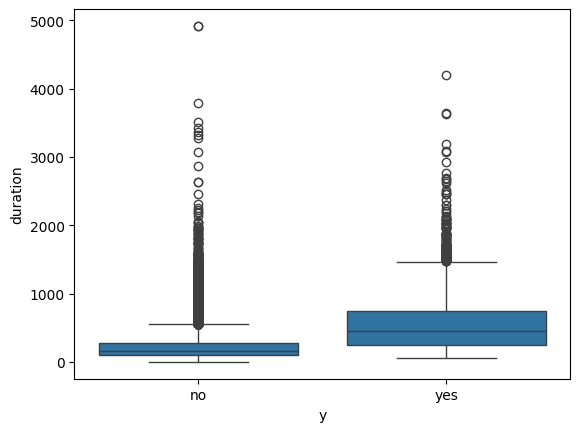

In [11]:

sns.boxplot(x="y", y="duration", data=df)



<Axes: xlabel='y', ylabel='income'>

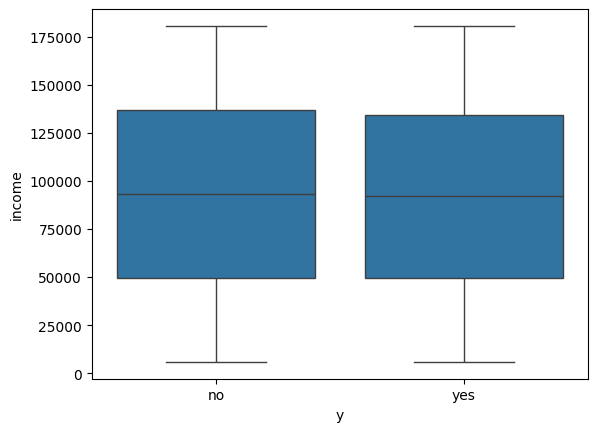

In [12]:
sns.boxplot(x="y", y="income", data=df)


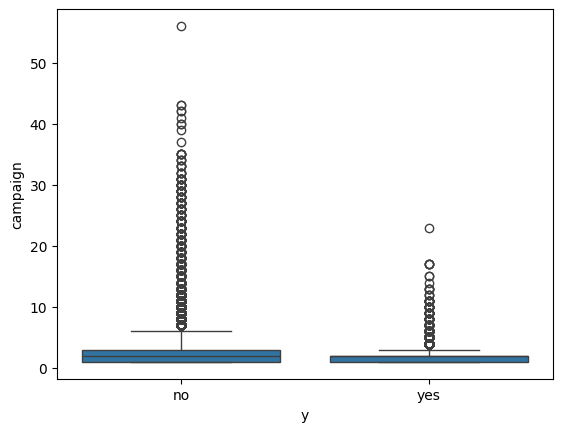

In [13]:
sns.boxplot(x="y", y="campaign", data=df)

plt.show()

<Axes: xlabel='y', ylabel='age'>

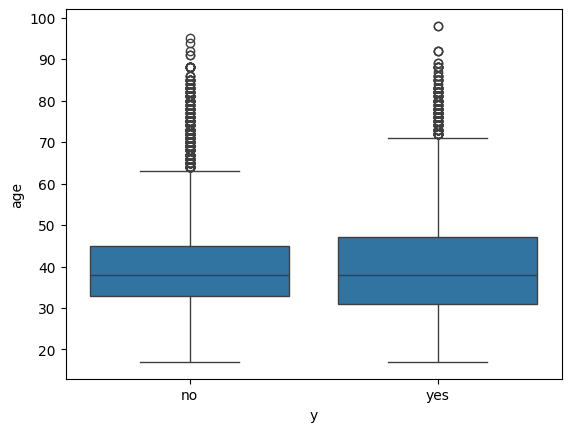

In [14]:
sns.boxplot(x="y", y="age", data=df)


¿Las llamadas más largas convierten más? - Lo que se podría decir es que la duración de las llamadas es mayor cuando se contrata. Siendo la media de 551.621387 frente 220.43020 segundos cuando no se contrata. Siendo la diferencia aun mayor con respecto a la mediana

¿Más ingresos → más probabilidad de “yes”? No, para ambas opciones, la media de los ingresos es similar.

¿Insistir en muchas campañas sirve o perjudica? aqui quizas podemos decir que cuantos mayores intentos de llamadas más se ha respondido que no.

Para el rango de edad, es mas amplio para los que contratan, aunque la media para ambas opciones se mantiene bastante similar cercana a los 40 años.

Por ahora vemos que las caracterisiticas personales no afectan mucho a la hora de contratar servicios, veamos ahora si afectan más las variables económicas


In [15]:
df.sample(2)

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,ID,duration_reduce,campaign_reduce,previous_reduce,income,kidhome,teenhome,dt_customer,numwebvisitsmonth,año,y_boo
9012,34.0,services,married,high.school,no registrado,0,0,telephone,453,2,no contacted,0,nonexistent,1.4,94.465,-41.8,4.967,5228.1,no,2017-04-13,bdf90c9a-c8c3-4c5c-8931-14d907bdbffa,453.0,2,0,64899,1,0,2012-04-30,14,2012,0
32127,40.0,services,married,basic.4y,no registrado,0,0,cellular,308,1,no contacted,1,failure,-1.8,92.893,-46.2,1.313,5099.1,no,2017-05-23,bc2e844e-8257-4ab2-a4a2-f39e38f745a1,308.0,1,1,151641,0,2,2014-03-24,12,2014,0


Veamos la media/mediana/ desviacion tipica de algunas variables numericas teniendo de referencia la variable "y".

In [16]:
variables_numericas =df.select_dtypes(include=[ "float64", "int64"])
var_num = variables_numericas.columns

In [17]:
estadisticos= ( df.groupby("y_boo")[var_num].agg(["mean", "median", "std"]))

estadisticos.T

y_boo                                0             1
age               mean       39.640109     40.541908
                  median     38.000000     38.000000
                  std         9.330693     13.006173
housing           mean        0.544973      0.563584
                  median      1.000000      1.000000
                  std         0.497980      0.495992
loan              mean        0.152506      0.147192
                  median      0.000000      0.000000
                  std         0.359515      0.354334
duration          mean      220.430208    551.621387
                  median    163.000000    449.000000
                  std       207.121495    398.398264
campaign          mean        2.632797      2.050784
                  median      2.000000      2.000000
                  std         2.876537      1.657519
previous          mean        0.132771      0.498968
                  median      0.000000      0.000000
                  std         0.409409      0.869920
emp.var.rate      mean        0.244499     -1.241247
                  median      1.100000     -1.800000
                  std         1.485663      1.626456
cons.price.idx    mean       93.603954     93.356991
                  median     93.918000     93.200000
                  std         0.556782      0.675203
cons.conf.idx     mean      -40.603748    -39.763109
                  median    -41.800000    -40.300000
                  std         4.397876      6.157534
euribor3m         mean        4.037035      2.674478
                  median      4.857000      1.405000
                  std         1.513786      1.905526
nr.employed       mean     5176.032480   5094.543064
                  median   5195.800000   5099.100000
                  std        64.707266     87.595834
duration_reduce   mean      218.612650    531.444538
                  median    163.000000    449.000000
                  std       191.829468    334.462083
campaign_reduce   mean        2.375799      1.997729
                  median      2.000000      2.000000
                  std         1.731002      1.385970
previous_reduce   mean        0.127844      0.441371
                  median      0.000000      0.000000
                  std         0.374889      0.692777
income            mean    93324.595031  92584.301197
                  median  93206.500000  92144.500000
                  std     50531.058916  50240.009719
kidhome           mean        1.004744      1.005161
                  median      1.000000      1.000000
                  std         0.815525      0.819047
teenhome          mean        0.998821      0.996903
                  median      1.000000      1.000000
                  std         0.815666      0.818553
numwebvisitsmonth mean       16.587850     16.604253
                  median     17.000000     17.000000
                  std         9.239240      9.239873
año               mean     2012.783206   2013.478530
                  median   2012.000000   2014.000000
                  std         0.858707      0.792903
y_boo             mean        0.000000      1.000000
                  median      0.000000      1.000000
                  std         0.000000      0.000000

In [18]:
variables_economicas = ["emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m"]

'Análisis de la variable: emp.var.rate'

y
no     0.244499
yes   -1.241247
Name: emp.var.rate, dtype: float64

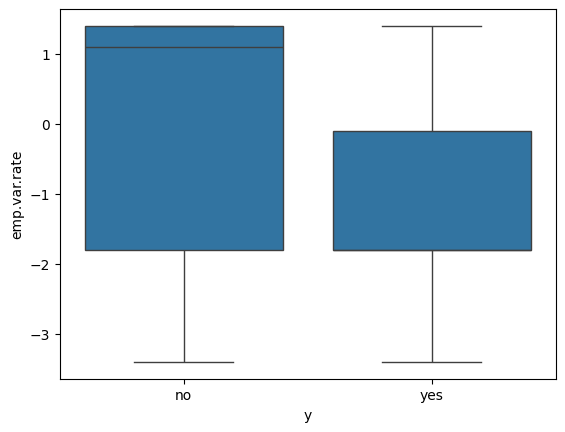

'Análisis de la variable: cons.price.idx'

y
no     93.603954
yes    93.356991
Name: cons.price.idx, dtype: float64

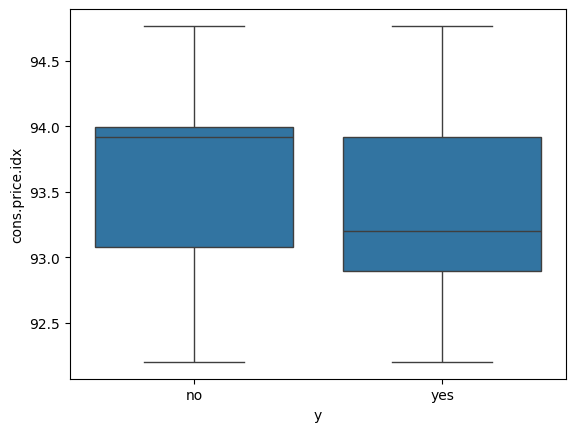

'Análisis de la variable: cons.conf.idx'

y
no    -40.603748
yes   -39.763109
Name: cons.conf.idx, dtype: float64

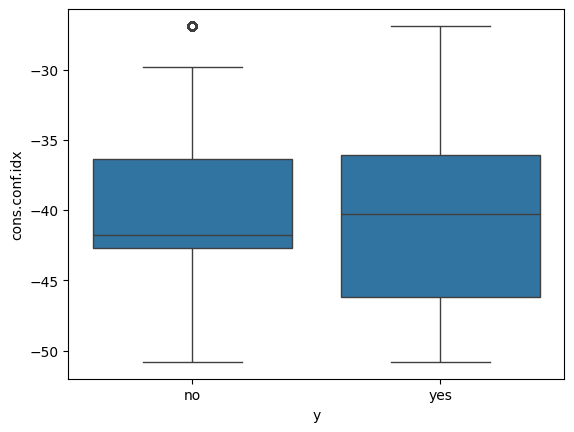

'Análisis de la variable: euribor3m'

y
no     4.037035
yes    2.674478
Name: euribor3m, dtype: float64

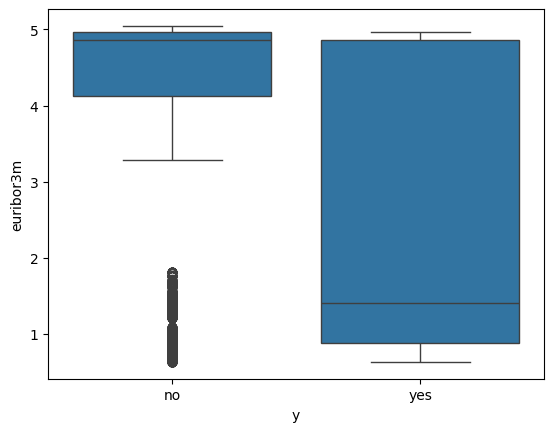

In [19]:
for var in variables_economicas:
    display(f"Análisis de la variable: {var}")
    display(df.groupby("y")[var].mean())
    sns.boxplot(x="y", y=var, data=df)
    plt.show()

Se puede observar claramente que la variable económica Euribor sí que afecta a la hora de la decisión, pues los que contratan tiene la media bastante mas baja que los que que no contratan.
Cuanto mas bajo es el euribor, mas gente contrata.
En general, para todas las variables económicas, los que contratan tienen medias mas bajas que los que no contratan. Por lo que se podría decir, que a mejores condiciones económicas más contratan, sin tener en cuenta sus variables propias.

In [20]:
df.sample(3)

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,ID,duration_reduce,campaign_reduce,previous_reduce,income,kidhome,teenhome,dt_customer,numwebvisitsmonth,año,y_boo
31630,38.0,blue-collar,married,basic.6y,No,0,0,cellular,481,2,no contacted,0,nonexistent,-1.8,92.893,-46.2,1.327,5099.1,yes,2016-02-13,225f7fcf-c4cf-419e-8334-9c76903f1d25,481.0,2,0,123233,0,1,2014-04-26,11,2014,1
20885,40.0,admin.,married,university.degree,no registrado,1,0,cellular,343,1,no contacted,0,nonexistent,1.4,93.444,-36.1,4.964,5228.1,no,2016-03-04,25ad4792-8e9b-4dd8-b8bc-9ed44948b458,343.0,1,0,55818,2,2,2013-01-24,6,2013,0
16719,31.0,entrepreneur,single,university.degree,No,1,0,cellular,329,1,no contacted,0,nonexistent,1.4,93.918,-42.7,4.857,5228.1,no,2016-03-31,4e9635f6-d19b-4e8d-aa1f-1e87764cc720,329.0,1,0,42406,1,1,2012-11-27,21,2012,0


In [21]:
df["income"].max()

np.int64(180802)

In [22]:
df["income"].min()

np.int64(5841)

Sabiendo que en la categoria income, el valor minimo es 5841 y el maximo es 180802, vamos a distribuirlos en categorias (bajo, medio, alto)
muy bajo: desde 5841 a 10.500
bajo: desde 10.500 a 30.500
medio: desde 30.500 a 60.500
alto: desde 60.500 a 100.000
muy alto: de 100.000 a 180802

In [23]:
df["income_group"]= pd.cut(df["income"], bins=[5841, 10500, 30500, 60500, 100000, 180802], labels=["muy bajo", "bajo", "medio", "alto", "muy alto"])


In [24]:
df.sample(5)

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,ID,duration_reduce,campaign_reduce,previous_reduce,income,kidhome,teenhome,dt_customer,numwebvisitsmonth,año,y_boo,income_group
20449,31.0,housemaid,married,basic.4y,No,0,0,cellular,145,8,no contacted,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no,2017-01-22,a1405900-a238-4420-8736-9c126b6ff040,145.0,7,0,31595,0,0,2013-07-11,23,2013,0,medio
23481,38.0,admin.,married,university.degree,no registrado,1,0,cellular,15,9,no contacted,0,nonexistent,1.4,93.444,-36.1,4.962,5228.1,no,2016-05-16,5061e68b-3801-444f-b67a-bf1a00718e18,15.0,7,0,16533,1,1,2013-02-07,17,2013,0,bajo
14397,32.0,blue-collar,married,basic.9y,no registrado,0,0,telephone,89,5,no contacted,0,nonexistent,1.4,93.918,-42.7,4.961,5228.1,no,2015-11-21,6ce1b008-64a2-4d44-9bab-380214498df2,89.0,5,0,46223,1,0,2012-12-19,10,2012,0,medio
7279,26.0,blue-collar,single,basic.9y,No,0,0,telephone,204,4,no contacted,0,nonexistent,1.1,93.994,-36.4,4.864,5191.0,no,2017-08-13,124fe5d9-458b-4254-8820-a2acf08a680d,204.0,4,0,148040,2,1,2012-08-09,27,2012,0,muy alto
18545,48.0,blue-collar,married,professional.course,No,0,0,cellular,22,25,no contacted,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no,2016-12-06,9092da0c-8cf7-4257-a43b-2f4b0fdb3b99,22.0,7,0,112300,2,2,2012-05-20,32,2012,0,muy alto


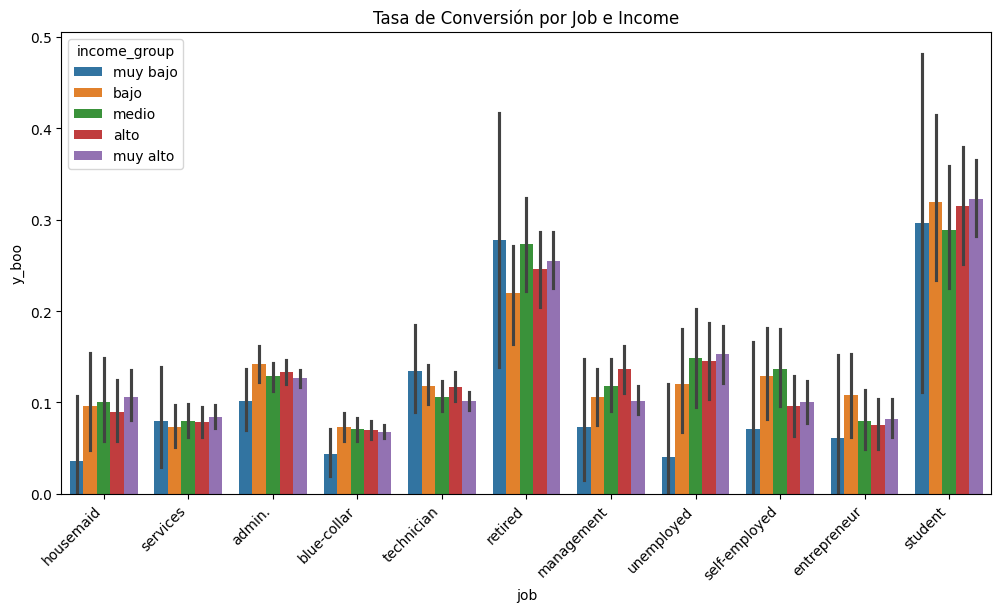

In [25]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=df,
    x="job",
    y="y_boo",
    hue="income_group",
)
plt.xticks(rotation=45, ha="right")
plt.title("Tasa de Conversión por Job e Income")
plt.show()

Resulta curioso, que tras haber realizado el análisis de categorias de trabajo y sueldo, los estudiantes sean independientemente del sueldo los que mayor tasa de conversion tienen, seguido de los retirados. Siendo los que menos contratan (menor tasa de conversion - y) los que tienen la profesion de "blue-collar" independientemente de la categoria salarial. Así como atendiendo solo a la categoria salarial, los que menos contratan son aquellos con un sueldo muy bajo, a excepcion de la categoria tecnica que en el grupo de menor sueldo son los que mas porcentaje de contratacion tienen.

Dado que hemos visto que el valor salarial parece no afectar proporcionalmente a la decision si contratar o no, veamos si esto se ve modificado al calcular la capacidad económica en función del numero de hijos. Por lo que vamos a crear dos columnas:
"total_hijos y "income_hijos"

In [26]:
df["total_kids"] = df["kidhome"] + df["teenhome"]


In [27]:
df["income_per_kid"] = df["income"] / (df["total_kids"] + 1)

In [28]:
ingresos = ["total_kids", "income_per_kid", "income"]

In [29]:
estadisticos_2= ( df.groupby("y_boo")[ingresos].agg(["mean", "median", "std"]))

estadisticos_2.T

y_boo                             0             1
total_kids     mean        2.003564      2.002064
               median      2.000000      2.000000
               std         1.152499      1.158329
income_per_kid mean    38259.721611  37863.394213
               median  30989.333333  30689.800000
               std     31936.709506  31521.326732
income         mean    93324.595031  92584.301197
               median  93206.500000  92144.500000
               std     50531.058916  50240.009719

In [36]:
df.groupby("y")[["duration", "campaign", "income", "euribor3m"]].mean()


,duration,campaign,income,euribor3m
y,,,,
no,220.430208,2.632797,93324.595031,4.037035
yes,551.621387,2.050784,92584.301197,2.674478


Se ha podido concluir que hay una relación negativa entre la cantidad de contactos y la posibilidad de contratación, a más contactos realizados más rechazo hay por parte de los clientes para contratar pero sí hay relación positiva como resulta lógico, que la duración de las llamadas es más extensa para aquellos que contratan. Volviendo a ver que la variable económica "income" no afecta realmente a la hora de querer contratar. Sino que son las variables macroeconómicas favorables las que sí impacta a la hora de contratar, a menor "euribor" más posibilidad de contratar.

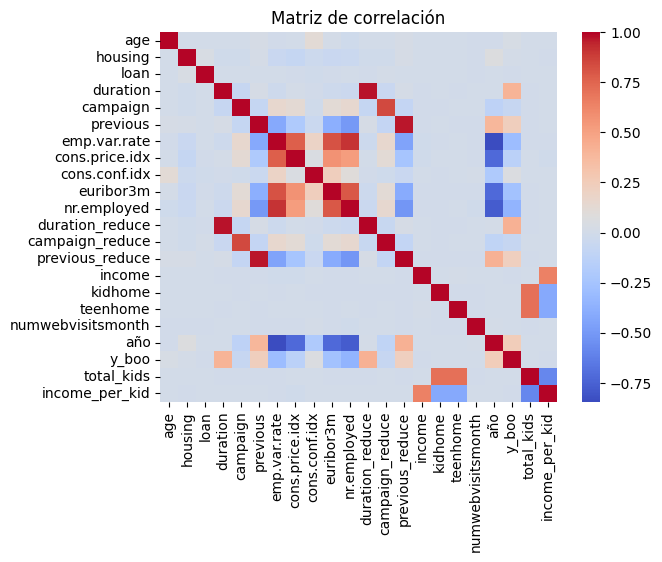

In [30]:
corr = df.select_dtypes(include="number").corr()

sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Matriz de correlación")
plt.show()


Vemos que hay poca correlación entre las variables numéricas y la variable objetivo "y_boo", lo que sugiere que las variables numéricas no tienen un impacto significativo en la decisión de contratar o no el producto. Destacamos la correlacion negativa entre las variables macro : Existe una correlación negativa fuerte entre euribor3m y emp.var.rate, lo que indica que niveles altos del tipo de interés se asocian con menores tasas de variación del empleo. Tambien hay correlacion negativa entre  previous y los valores macroeconomicos de emp.var.rate, cons.price.idx, euribor3m.
Tambien hay correlacion positiva fuerte entre euribor3m y emp.var.rate, entre nr.employed y emp.var rate.


El análisis de correlación no muestra relaciones lineales fuertes entre la mayoría de variables explicativas y la variable objetivo, salvo en variables relacionadas con la duración de la llamada. Las variables macroeconómicas presentan altas correlaciones entre sí, lo que sugiere multicolinealidad.
Las variables sociodemográficas muestran diferencias entre grupos, aunque con menor capacidad explicativa, mientras que las variables macroeconómicas presentan relaciones fuertes entre sí.

In [37]:
df.to_csv("../data/bank-finalizado.csv", index=False)